In [3]:
from visualization import plot_dist
import numpy as np
from frozen_lake_env import ModifiedFrozenLake, MAPS

In [4]:

# Note: Changed to match the previous script so the plots align, 
# but feel free to switch back to '11x11dzigzag' if needed!
map_name = 'windycliff' 


# 1. Environment Setup
desc = np.array(MAPS[map_name], dtype='c')
desc[desc == b'W'] = b'H'
desc[desc == b'G'] = b'F'

env = ModifiedFrozenLake(
    n_action=4, desc=desc, step_penalization=0, max_reward=0, 
    min_reward=-1, never_done=True, cyclic_mode=True, 
    goal_attractor=0., slippery=0
)


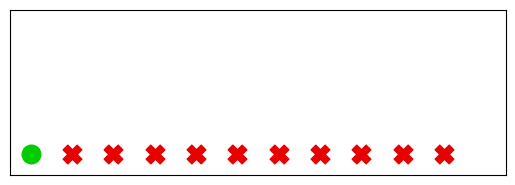

In [6]:
plot_dist(desc)

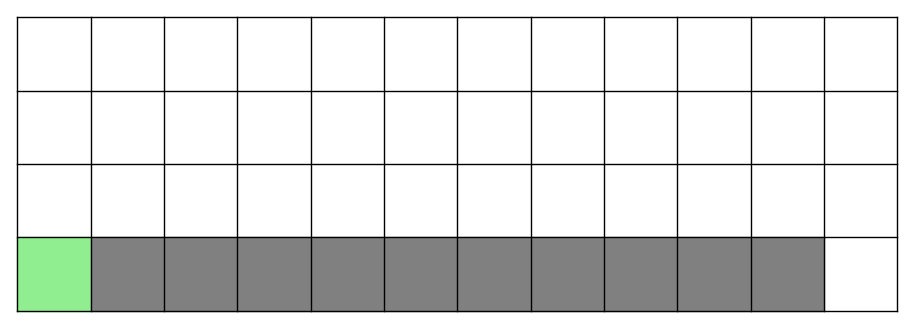

In [14]:
# draw a 4x12 grid 
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
# Plot the grid
for i in range(desc.shape[0] + 1):
    plt.plot([0, desc.shape[1]], [i, i], color='black', linewidth=1)
for j in range(desc.shape[1] + 1):
    plt.plot([j, j], [0, desc.shape[0]], color='black', linewidth=1)
# Fill the cells based on the description
for i in range(desc.shape[0]):
    for j in range(desc.shape[1]):
        cell_type = desc[i, j]
        if cell_type == b'H':
            plt.fill_between([j, j+1], [i, i], [i+1, i+1], color='gray')
        # elif cell_type == b'F':
        #     plt.fill_between([j, j+1], [i, i], [i+1, i+1], color='lightgreen')
        elif cell_type == b'S':
            plt.fill_between([j, j+1], [i, i], [i+1, i+1], color='lightgreen')
# Set limits and labels
plt.xlim(-0.10, desc.shape[1]+0.1)
plt.ylim(-0.10, desc.shape[0]+0.1)
plt.gca().set_aspect('equal', adjustable='box')
# turn off 
plt.axis('off')
# invert the y axis
plt.gca().invert_yaxis()

Environment diagram saved to windy_cliff_diagram.png


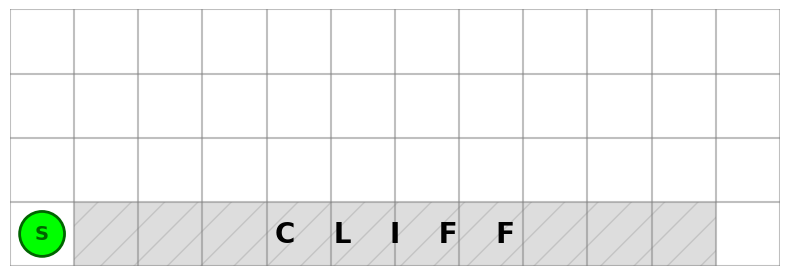

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_windy_cliff_environment(save_path=None):
    """
    Creates a visualization of the 4x12 Windy Cliff environment.
    """
    rows = 4
    cols = 12

    # 1. Setup the figure and axes
    # We use a figsize that roughly matches the 12:4 aspect ratio
    fig, ax = plt.subplots(figsize=(8, 3)) 
    
    # Set limits based on grid size (0 to N)
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    
    # Crucial: ensure cells are perfectly square
    ax.set_aspect('equal')

    # 2. Draw prominent grid lines
    # Set ticks at every integer interval
    ax.set_xticks(np.arange(0, cols + 1, 1))
    ax.set_yticks(np.arange(0, rows + 1, 1))
    
    # Turn on the grid based on these ticks
    ax.grid(which='major', color='gray', linestyle='-', linewidth=1.5, alpha=0.5)
    
    # Remove tick labels and exterior ticks for a cleaner look
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(axis='both', which='both', length=0) # Hide tick marks

    # --- Add Environmental Elements ---

    # 3. Shaded region for "The Cliff"
    # The cliff is the bottom row (y=0 to 1), typically spanning columns 1 to 10.
    # Rectangle defined by bottom-left xy, width, height.
    cliff_start_x = 1
    cliff_width = cols - 2 # Spans 10 cells
    
    cliff_patch = patches.Rectangle(
        (cliff_start_x, 0),   # (x,y) bottom-left corner
        cliff_width,          # width
        1,                    # height
        linewidth=0,
        facecolor='#555555',  # Dark gray
        alpha=0.2,            # Semi-transparent
        hatch='/',                  # Add diagonal lines for "danger" texture
        edgecolor="#5e5e5e",        # Lighter hatch/edge color
        zorder=1
    )
    ax.add_patch(cliff_patch)
    
    # Add "CLIFF" text label in the middle of the danger zone
    ax.text(cliff_start_x + cliff_width/2, 0.5, 'C    L    I    F    F', 
            horizontalalignment='center', verticalalignment='center', 
            fontsize=20, color='black', fontweight='bold', zorder=2, alpha=1.0)


    # 4. Green circle for Start State (Bottom Left)
    # Bottom left cell center is at (0.5, 0.5)
    start_center = (0.5, 0.5)
    start_circle = patches.Circle(
        start_center, 
        radius=0.35, 
        linewidth=2, 
        edgecolor='darkgreen', 
        facecolor='lime', 
        zorder=10 # Ensure it sits on top of grid lines
    )
    ax.add_patch(start_circle)
    
    # Add 'S' text inside circle
    ax.text(start_center[0], start_center[1], 'S', 
            horizontalalignment='center', verticalalignment='center', 
            fontsize=14, fontweight='bold', color='darkgreen', zorder=11)

    # Final formatting
    # Remove the outer spine frame for a cleaner "inset" look
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True)
        print(f"Environment diagram saved to {save_path}")
    
    plt.show()

if __name__ == '__main__':
    plot_windy_cliff_environment(save_path='windy_cliff_diagram.png')